In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import h5py
import librosa

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelBinarizer, OneHotEncoder

from keras.models import Sequential
from keras.layers import Input, Reshape, Dense, Dropout, SpatialDropout2D, Conv2D, MaxPooling2D, BatchNormalization, Flatten
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2

from ISLP import confusion_table

c:\Users\tyler\miniconda3\envs\data-science\Lib\site-packages\h5py\__init__.py:36: UserWarning: h5py is running against HDF5 1.14.6 when it was built against 1.14.5, this may cause problems
  _warn(("h5py is running against HDF5 {0} when it was built against {1}, "


# 1. Data Sourcing and Preprocessing

We will use neural networks to classify birds from their sound. The original data was taken from this [Birdcall competition data](https://www.kaggle.com/datasets/rohanrao/xeno-canto-bird-recordings-extended-a-m) (which was originally from the crowd-sourced wildlife sound archive [Xeno-Canto](https://xeno-canto.org/)), but we will be using a subsetted and processed version of the data (found [here](https://github.com/mendible/5322/tree/main/Homework%203)) that computed the _spectrograms_ of the sound files (`select_birds.ipynb`) for 12 species of birds and stored them in `bird_spectrograms.hdf5`. A spectrogram is a visual representation of sound frequency over time; you can think of it as an _image_ of a sound. Importantly, this will allow us to classify bird calls using image classification techniques (in particular, convolutional neural networks).

In [2]:
data_file = "data/bird_spectrograms.hdf5"
f = h5py.File(data_file, "r")

In [3]:
species = list(f.keys())
for spec in f.keys():
    print(f"{spec}: {f[spec].shape}")

amecro: (128, 517, 66)
amerob: (128, 517, 172)
bewwre: (128, 517, 144)
bkcchi: (128, 517, 45)
daejun: (128, 517, 125)
houfin: (128, 517, 84)
houspa: (128, 517, 630)
norfli: (128, 517, 37)
rewbla: (128, 517, 187)
sonspa: (128, 517, 263)
spotow: (128, 517, 137)
whcspa: (128, 517, 91)


The output above shows the species code along with the dimensions of the data for that species. For example, "amecro" is the code for the American Crow; 128 (frequency) by 517 (time) is the dimensions of the spectrograms, while 66 is the number of samples we have for the American Crow. The codes and their correspond species are:

- **amecro**: American Crow
- **amerob**: American Robin
- **bewwre**: Berwick's Wren
- **bkcchi**: Black-capped Chickadee
- **daejun**: Dark-eyed Junco
- **houfin**: House Finch
- **houspa**: House Sparrow
- **norfli**: Northern Flicker
- **rewbla**: Red-winged Blackbird
- **sonspa**: Song Sparrow
- **spotow**: Spotted Towhee
- **whcspa**: White-crowned Sparrow

Looking at the number of samples for each species, we see that there is a somewhat large class imbalance. In particular, there are 630 samples for the House Sparrow, but only 37 samples for the Northern Flicker. Since we only care about training a model to distinguish the birds (and not about the relative frequencies of birds in the dataset), we will use undersampling to balance the classes so that the most common class has at most twice as many samples as the least common class.

In [4]:
height, width = 128, 517  # height and width of spectrograms

def get_data(species):
    # number of samples for each class
    num_class_samples = [f[spec].shape[2] for spec in species]
    max_class_samples = 2*np.min(num_class_samples)
    num_class_samples = [min(m,max_class_samples) for m in num_class_samples]

    n = np.sum(num_class_samples)  # total number of samples

    # n; each (flattened) sample is length height*width
    X = np.zeros((n,height*width))
    y = np.zeros(n, dtype="<U6")  # we know that the species codes are all 6 characters

    j = 0
    for i,spec in enumerate(species):
        m = num_class_samples[i]

        # grab first m samples
        species_data = f[spec][:,:,:m]  # 128,517,m

        # equivalent to X[j] = species_data[:,:,j].flatten() for all j
        X[j:j+m] = species_data.transpose(2,0,1).reshape(m,-1)
        y[j:j+m] = spec

        print(f"{spec}: {j},{j+m-1}  ({m})")

        j += m
    
    # the values of X are (approximately) between -80 and 0
    X_scaled = (X+80)/80

    if len(species)==2:
        enc = LabelBinarizer()
        y_encoded = enc.fit_transform(y)
    else:
        enc = OneHotEncoder(sparse_output=False)
        y_encoded = enc.fit_transform(y.reshape(-1,1))

    return X_scaled,y_encoded,enc

In [5]:
# Binary Model Data
Xb, yb, encb = get_data(species=["amecro","rewbla"])

amecro: 0,65  (66)
rewbla: 66,197  (132)


In [6]:
print(encb.classes_)
print(Xb.shape,yb.shape)
print(np.min(Xb),np.max(Xb))

['amecro' 'rewbla']
(198, 66176) (198, 1)
0.0 1.0000000238418578


In [7]:
# sanity check
print(encb.inverse_transform(yb[67]))
print(Xb[67])
print(1+f["rewbla"][:,:,1].flatten()/80)

['rewbla']
[0.17991581 0.3092772  0.34895105 ... 0.         0.         0.        ]
[0.17991581 0.3092772  0.34895105 ... 0.         0.         0.        ]


In [8]:
# Multi-class Model Data
Xm, ym, encm = get_data(species=species)

amecro: 0,65  (66)
amerob: 66,139  (74)
bewwre: 140,213  (74)
bkcchi: 214,258  (45)
daejun: 259,332  (74)
houfin: 333,406  (74)
houspa: 407,480  (74)
norfli: 481,517  (37)
rewbla: 518,591  (74)
sonspa: 592,665  (74)
spotow: 666,739  (74)
whcspa: 740,813  (74)


In [9]:
print(encm.categories_)
print(Xm.shape,ym.shape)
print(np.min(Xm),np.max(Xm))

[array(['amecro', 'amerob', 'bewwre', 'bkcchi', 'daejun', 'houfin',
       'houspa', 'norfli', 'rewbla', 'sonspa', 'spotow', 'whcspa'],
      dtype='<U6')]
(814, 66176) (814, 12)
0.0 1.0000000238418578


In [10]:
# sanity check
print(encm.inverse_transform(ym[[0,66,140,214,259,333,407,481,518,592,666,740]])[:,0])
print(Xm[340])
print(1+f["houfin"][:,:,7].flatten()/80)

['amecro' 'amerob' 'bewwre' 'bkcchi' 'daejun' 'houfin' 'houspa' 'norfli'
 'rewbla' 'sonspa' 'spotow' 'whcspa']
[0.13432064 0.11005001 0.07989178 ... 0.         0.         0.15212765]
[0.13432064 0.11005001 0.07989178 ... 0.         0.         0.15212765]


In [49]:
code_to_name = {
    "amecro": "American Crow",
    "amerob": "American Robin",
    "bewwre": "Berwick's Wren",
    "bkcchi": "Black-capped Chickadee",
    "daejun": "Dark-eyed Junco",
    "houfin": "House Finch",
    "houspa": "House Sparrow",
    "norfli": "Northern Flicker",
    "rewbla": "Red-winged Blackbird",
    "sonspa": "Song Sparrow",
    "spotow": "Spotted Towhee",
    "whcspa": "White-crowned Sparrow"
}

def to_names(prediction):
    return [code_to_name[code] for code in prediction]

# 2. Data Modeling

## 2.1 Binary Model: amecro vs. rewbla

First, we will build a model to distinguish between American Crows (amecro) and Red-winged Blackbirds (rewbla). We will try a "lightweight" CNN without much regularization as well as a more complex CNN with more regularization.

In [11]:
# Split into training and test sets (70-30 split)
Xb_train,Xb_test,yb_train,yb_test = train_test_split(
    Xb,
    yb,
    train_size=0.7,
    random_state=5322
)

print(Xb_train.shape, yb_train.shape)
print(Xb_test.shape, yb_test.shape)

(138, 66176) (138, 1)
(60, 66176) (60, 1)


In [19]:
CNNb_light = Sequential([
    # input + reshape
    Input(shape=(height*width,)),
    Reshape(target_shape=(height,width,1)),

    # convolution + pooling block
    Conv2D(filters=16, kernel_size=(3,3), padding="same", activation="relu"),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2,2)),
    SpatialDropout2D(0.2),

    # flatten + fully connected layers
    Flatten(),
    Dense(units=32, activation="relu"),
    BatchNormalization(),
    Dropout(0.2),
    Dense(units=1, activation="sigmoid")
])

CNNb_light.compile(
    optimizer=Adam(learning_rate=3e-4),  # A Recipe for Training Neural Networks
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [20]:
histb_light = CNNb_light.fit(
    Xb_train, yb_train,
    epochs=30,
    batch_size=4,  # remember, there are only 138 training samples
    validation_data=(Xb_test, yb_test)
)

Epoch 1/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - accuracy: 0.4932 - loss: 1.2423 - val_accuracy: 0.5833 - val_loss: 0.6961
Epoch 2/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.5987 - loss: 0.7309 - val_accuracy: 0.3667 - val_loss: 0.7491
Epoch 3/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.6067 - loss: 0.6461 - val_accuracy: 0.3333 - val_loss: 0.7551
Epoch 4/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - accuracy: 0.6268 - loss: 0.7264 - val_accuracy: 0.3667 - val_loss: 0.7474
Epoch 5/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - accuracy: 0.6494 - loss: 0.7348 - val_accuracy: 0.4000 - val_loss: 0.7237
Epoch 6/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.6964 - loss: 0.5838 - val_accuracy: 0.4833 - val_loss: 0.6962
Epoch 7/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - accuracy: 0.6448 - loss: 0.5695 - val_accuracy: 0.6000 - val_loss: 0.6514
Epoch 8/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.7598 - loss: 0.5533 - val_accuracy: 0.6333 - v

In [25]:
CNNb_heavy = Sequential([
    # input + reshape
    Input(shape=(height*width,)),
    Reshape(target_shape=(height,width,1)),

    # first convolution + pooling block
    Conv2D(filters=16, kernel_size=(3,3), padding="same", activation="relu",kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2,2)),

    # second convolution + pooling block
    Conv2D(filters=32, kernel_size=(3,3), padding="same", activation="relu",kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2,2)),
    SpatialDropout2D(0.3),

    # flatten + fully connected layers
    Flatten(),
    Dense(units=64, activation="relu",kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    Dense(units=1, activation="sigmoid")
])

CNNb_heavy.compile(
    optimizer=Adam(learning_rate=3e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [26]:
histb_heavy = CNNb_heavy.fit(
    Xb_train, yb_train,
    epochs=30,
    batch_size=4,
    validation_data=(Xb_test, yb_test)
)

Epoch 1/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 4s 65ms/step - accuracy: 0.5812 - loss: 1.0119 - val_accuracy: 0.3833 - val_loss: 0.8606
Epoch 2/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 58ms/step - accuracy: 0.7350 - loss: 0.7494 - val_accuracy: 0.4167 - val_loss: 0.8688
Epoch 3/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - accuracy: 0.7618 - loss: 0.6462 - val_accuracy: 0.5167 - val_loss: 0.8302
Epoch 4/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step - accuracy: 0.8137 - loss: 0.6250 - val_accuracy: 0.5833 - val_loss: 0.8268
Epoch 5/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step - accuracy: 0.8013 - loss: 0.6065 - val_accuracy: 0.5333 - val_loss: 1.0089
Epoch 6/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - accuracy: 0.7586 - loss: 0.6247 - val_accuracy: 0.3667 - val_loss: 1.2152
Epoch 7/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - accuracy: 0.7341 - loss: 0.6214 - val_accuracy: 0.3333 - val_loss: 1.2954
Epoch 8/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 59ms/step - accuracy: 0.8528 - loss: 0.5239 - val_accuracy: 0.4667 - v

In [32]:
def plot_history(hist):
    history = hist.history

    plt.figure(figsize=(14, 6))
    epochs = range(1, len(history["loss"])+1)

    # Loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs,history["loss"],"o-",color="b",linewidth=2,markersize=5,label="Training Loss")
    plt.plot(epochs,history["val_loss"],"o-",color="orange",linewidth=2,markersize=5,label="Test Loss")
    plt.xlabel("Epochs",fontsize=18)
    plt.ylabel("Loss",fontsize=18)
    plt.grid(visible=True,linestyle="--",alpha=0.5)
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.legend(fontsize=14,frameon=True)

    # Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epochs,history["accuracy"],"o-",color="b",linewidth=2,markersize=5,label="Training Accuracy")
    plt.plot(epochs,history["val_accuracy"],"o-",color="orange",linewidth=2,markersize=5,label="Test Accuracy")
    plt.xlabel("Epochs",fontsize=18)
    plt.ylabel("Accuracy",fontsize=18)
    plt.ylim(0, 1.05)
    plt.grid(visible=True,linestyle="--",alpha=0.5)
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.legend(fontsize=14,frameon=True)

    plt.tight_layout()
    plt.show()

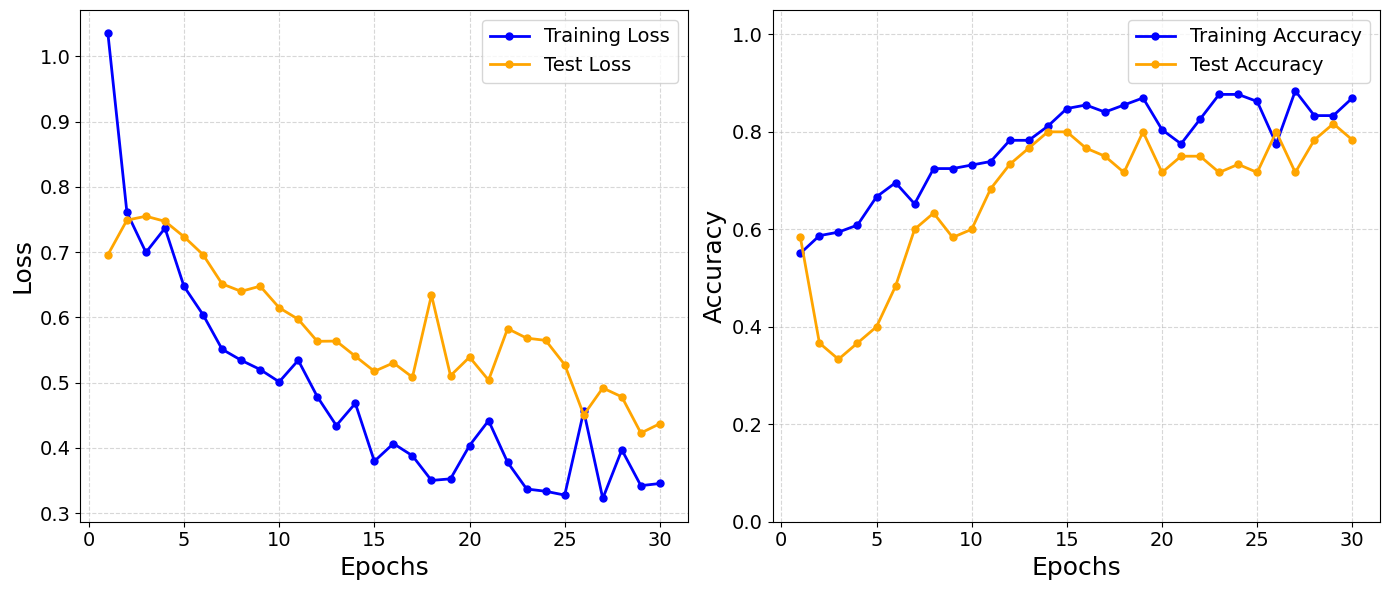

Test Accuracy: 78.33%


In [35]:
plot_history(histb_light)
print("Test Accuracy: {:.2f}%".format(CNNb_light.evaluate(Xb_test, yb_test, verbose=0)[1]*100))

In [65]:
yb_pred = CNNb_light.predict(Xb_test, verbose=0)
yb_pred = np.where(yb_pred>0.5, 1, 0)
yb_pred = encb.inverse_transform(yb_pred)
yb_truth = encb.inverse_transform(yb_test)
confusion_table(
    to_names(yb_pred),
    to_names(yb_truth)
)

Truth,American Crow,Red-winged Blackbird
Predicted,,
American Crow,13,6
Red-winged Blackbird,7,34


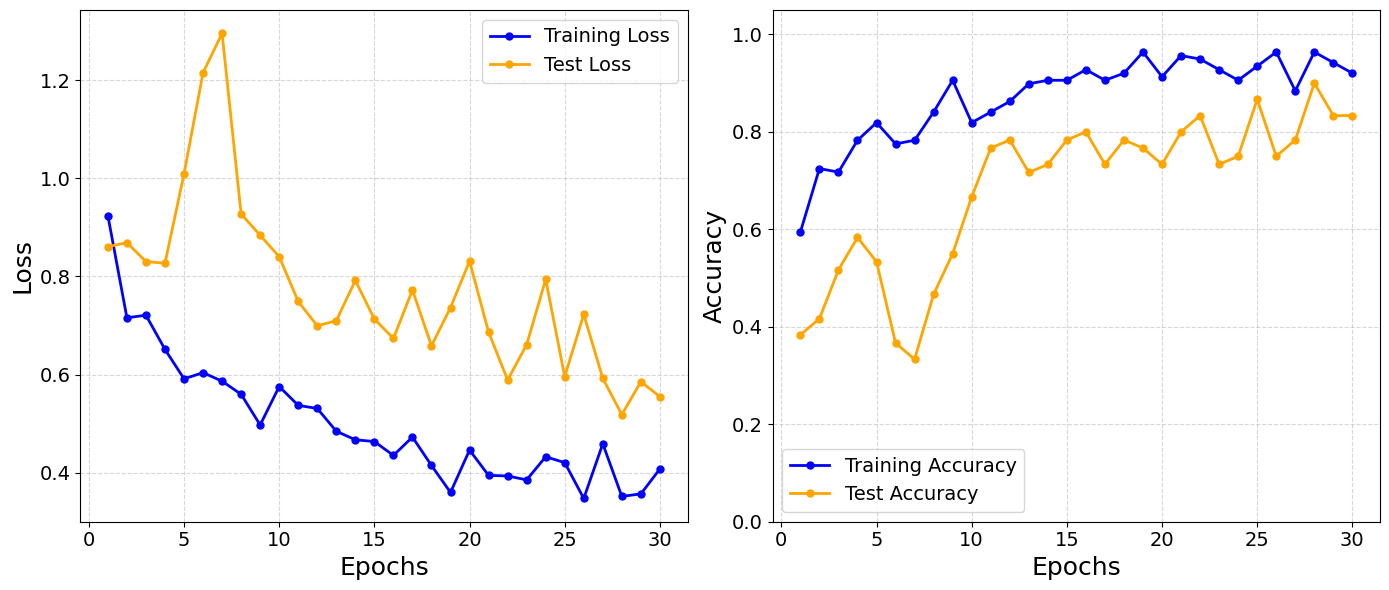

Test Accuracy: 83.33%


In [63]:
plot_history(histb_heavy)
print("Test Accuracy: {:.2f}%".format(CNNb_heavy.evaluate(Xb_test, yb_test, verbose=0)[1]*100))

In [66]:
yb_pred = CNNb_heavy.predict(Xb_test, verbose=0)
yb_pred = np.where(yb_pred>0.5, 1, 0)
yb_pred = encb.inverse_transform(yb_pred)
yb_truth = encb.inverse_transform(yb_test)
confusion_table(
    to_names(yb_pred),
    to_names(yb_truth)
)

Truth,American Crow,Red-winged Blackbird
Predicted,,
American Crow,13,3
Red-winged Blackbird,7,37


## 2.2 Multi-class Model

Now, we will build a model to distinguish between all 12 species. Again, we will try a "lightweight" CNN without much regularization and a more complex CNN with more regularization.

In [38]:
# Split into training and test sets (70-30 split)
Xm_train,Xm_test,ym_train,ym_test = train_test_split(
    Xm,
    ym,
    train_size=0.7,
    random_state=5322
)

print(Xm_train.shape, ym_train.shape)
print(Xm_test.shape, ym_test.shape)

(569, 66176) (569, 12)
(245, 66176) (245, 12)


In [58]:
CNNm_light = Sequential([
    # input + reshape
    Input(shape=(height*width,)),
    Reshape(target_shape=(height,width,1)),

    # first convolution + pooling block
    Conv2D(filters=32, kernel_size=(3,3), padding="same", activation="relu"),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2,2)),

    # second convolution + pooling block
    Conv2D(filters=64, kernel_size=(3,3), padding="same", activation="relu"),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2,2)),
    SpatialDropout2D(0.25),

    # flatten + fully connected layers
    Flatten(),
    Dense(units=128, activation="relu"),
    BatchNormalization(),
    Dropout(0.25),
    Dense(units=12, activation="softmax")
])

CNNm_light.compile(
    optimizer=Adam(learning_rate=3e-4),  # A Recipe for Training Neural Networks
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [59]:
histm_light = CNNm_light.fit(
    Xm_train, ym_train,
    epochs=50,
    batch_size=16,  # training set has 569 samples
    validation_data=(Xm_test, ym_test)
)

Epoch 1/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 13s 301ms/step - accuracy: 0.1231 - loss: 3.2058 - val_accuracy: 0.0816 - val_loss: 2.5635
Epoch 2/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 13s 368ms/step - accuracy: 0.2485 - loss: 2.3533 - val_accuracy: 0.1020 - val_loss: 2.6783
Epoch 3/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 14s 388ms/step - accuracy: 0.4549 - loss: 1.7582 - val_accuracy: 0.0939 - val_loss: 2.9504
Epoch 4/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 14s 395ms/step - accuracy: 0.7207 - loss: 1.0371 - val_accuracy: 0.0939 - val_loss: 2.9487
Epoch 5/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 14s 389ms/step - accuracy: 0.8612 - loss: 0.5789 - val_accuracy: 0.0980 - val_loss: 3.2017
Epoch 6/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 14s 400ms/step - accuracy: 0.9348 - loss: 0.3084 - val_accuracy: 0.0939 - val_loss: 3.3679
Epoch 7/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 14s 392ms/step - accuracy: 0.9572 - loss: 0.2666 - val_accuracy: 0.0939 - val_loss: 3.5705
Epoch 8/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 14s 383ms/step - accuracy: 0.9885 - loss: 0.1422 - val_accu

In [43]:
CNNm_heavy = Sequential([
    # input + reshape
    Input(shape=(height*width,)),
    Reshape(target_shape=(height,width,1)),

    # first convolution + pooling block
    Conv2D(filters=32, kernel_size=(3,3), padding="same", activation="relu",kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2,2)),

    # second convolution + pooling block
    Conv2D(filters=64, kernel_size=(3,3), padding="same", activation="relu",kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2,2)),

    # third convolution + pooling block
    Conv2D(filters=128, kernel_size=(3,3), padding="same", activation="relu",kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2,2)),
    SpatialDropout2D(0.25),

    # flatten + fully connected layers
    Flatten(),
    Dense(units=256, activation="relu",kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    Dropout(0.25),
    Dense(units=12, activation="softmax")
])

CNNm_heavy.compile(
    optimizer=Adam(learning_rate=3e-4),  # A Recipe for Training Neural Networks
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [44]:
histm_heavy = CNNm_heavy.fit(
    Xm_train, ym_train,
    epochs=50,
    batch_size=16,  # training set has 569 samples
    validation_data=(Xm_test, ym_test)
)

Epoch 1/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 18s 428ms/step - accuracy: 0.1449 - loss: 4.3004 - val_accuracy: 0.0694 - val_loss: 8.6101
Epoch 2/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 20s 563ms/step - accuracy: 0.3862 - loss: 2.6536 - val_accuracy: 0.0898 - val_loss: 17.6946
Epoch 3/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 20s 548ms/step - accuracy: 0.5781 - loss: 2.1656 - val_accuracy: 0.0898 - val_loss: 25.6664
Epoch 4/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 20s 553ms/step - accuracy: 0.7162 - loss: 1.7895 - val_accuracy: 0.0898 - val_loss: 37.1979
Epoch 5/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 20s 554ms/step - accuracy: 0.5807 - loss: 2.2708 - val_accuracy: 0.0898 - val_loss: 47.1797
Epoch 6/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 20s 545ms/step - accuracy: 0.7989 - loss: 1.5487 - val_accuracy: 0.0898 - val_loss: 58.6420
Epoch 7/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 19s 536ms/step - accuracy: 0.8958 - loss: 1.2578 - val_accuracy: 0.0898 - val_loss: 58.6233
Epoch 8/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 19s 536ms/step - accuracy: 0.9280 - loss: 1.1465 - va

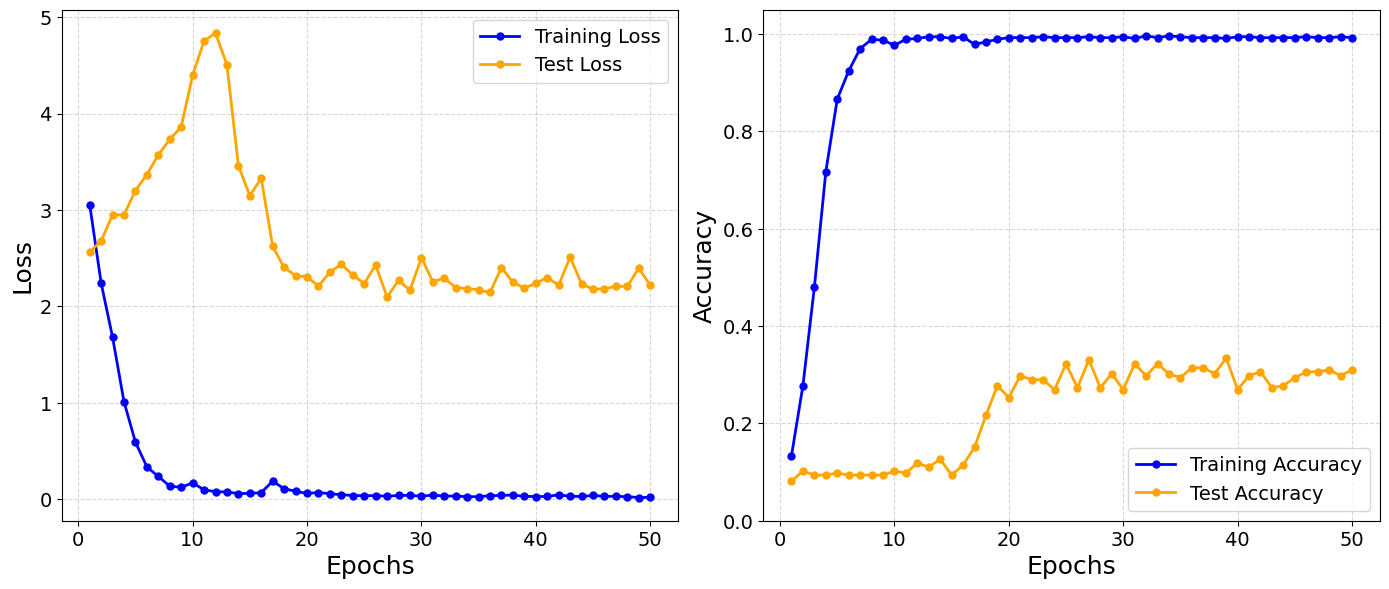

In [67]:
plot_history(histm_light)

In [73]:
ym_pred = encm.inverse_transform(
    # choose index with largest probability, one-hot encode it, and then invert
    OneHotEncoder(sparse_output=False).fit_transform(np.argmax(CNNm_light.predict(Xm_test, verbose=0), axis=1).reshape(-1,1))
)[:,0]
ym_truth = encm.inverse_transform(ym_test)[:,0]
confusion_table(ym_pred,ym_truth)

Truth,amecro,amerob,bewwre,bkcchi,daejun,houfin,houspa,norfli,rewbla,sonspa,spotow,whcspa
Predicted,,,,,,,,,,,,
amecro,14,1,1,2,2,2,4,3,3,1,2,5
amerob,0,7,2,2,2,3,0,2,5,1,0,0
bewwre,0,1,2,0,2,0,0,0,0,1,0,0
bkcchi,1,0,0,1,0,1,0,0,0,0,2,0
daejun,1,1,4,0,7,1,2,0,1,3,1,4
houfin,1,0,2,1,0,8,3,0,0,0,1,1
houspa,0,0,0,1,0,0,5,0,0,1,0,0
norfli,0,0,0,0,0,1,0,0,0,0,0,0
rewbla,3,3,1,2,0,4,5,4,10,1,3,3


<Axes: xlabel='Truth', ylabel='Predicted'>

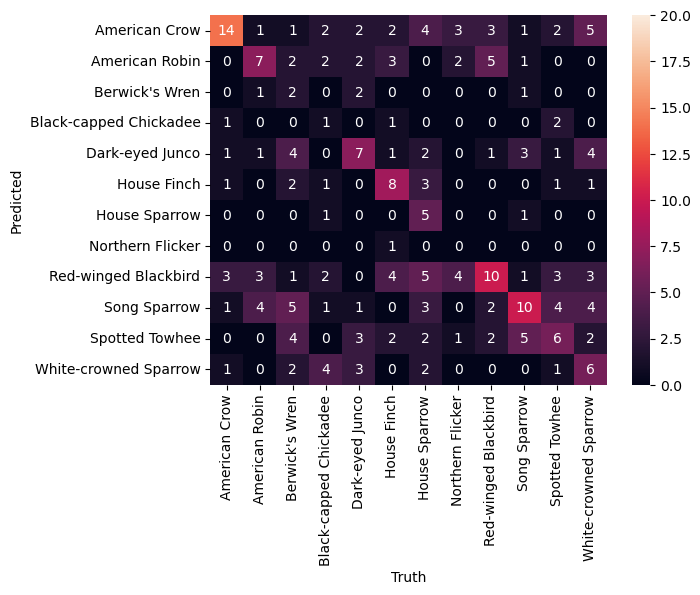

In [74]:
# vmax = 20 so that color is comparable with next heatmap
sns.heatmap(confusion_table(to_names(ym_pred),to_names(ym_truth)), annot=True, vmax=20)

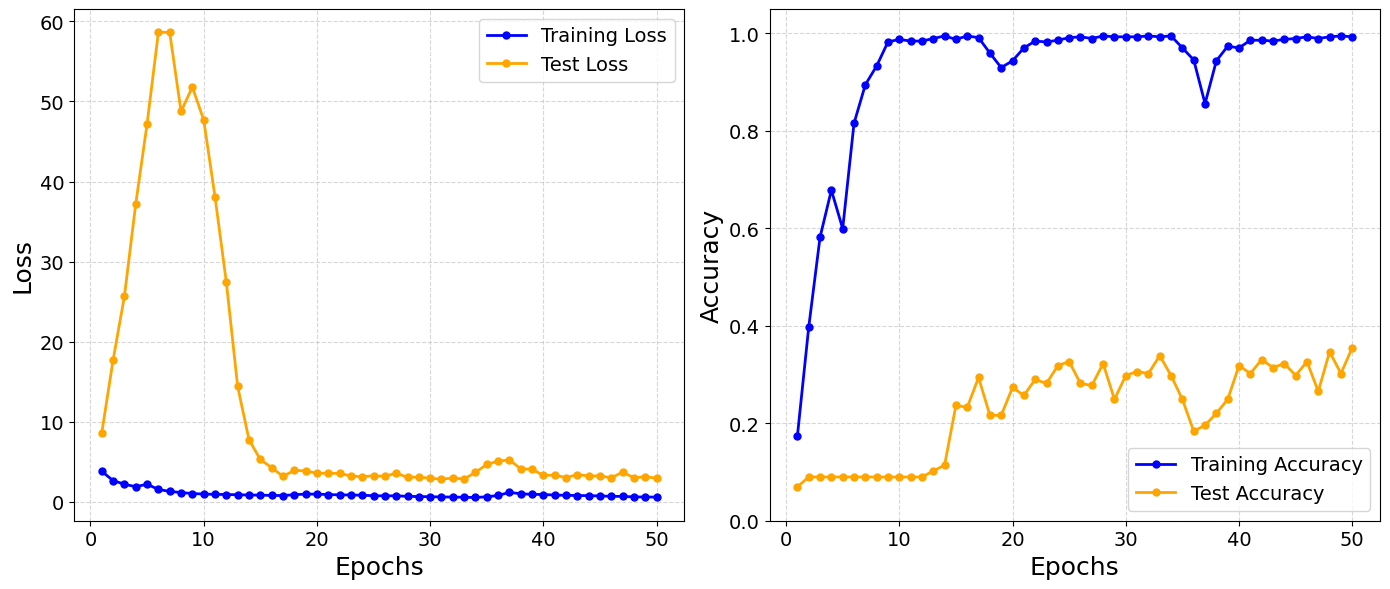

In [48]:
plot_history(histm_heavy)

In [75]:
ym_pred = encm.inverse_transform(
    # choose index with largest probability, one-hot encode it, and then invert
    OneHotEncoder(sparse_output=False).fit_transform(np.argmax(CNNm_heavy.predict(Xm_test, verbose=0), axis=1).reshape(-1,1))
)[:,0]
ym_truth = encm.inverse_transform(ym_test)[:,0]
confusion_table(ym_pred,ym_truth)

Truth,amecro,amerob,bewwre,bkcchi,daejun,houfin,houspa,norfli,rewbla,sonspa,spotow,whcspa
Predicted,,,,,,,,,,,,
amecro,14,0,0,1,1,1,0,0,0,1,1,1
amerob,0,12,2,1,1,4,0,2,5,1,0,1
bewwre,1,1,3,1,0,2,1,0,1,4,0,1
bkcchi,1,0,0,1,0,0,1,0,0,0,1,0
daejun,2,0,3,2,9,2,0,1,1,4,5,6
houfin,0,0,2,0,0,3,0,1,0,0,0,0
houspa,1,0,2,0,2,6,20,2,4,3,1,2
norfli,3,2,0,1,0,1,2,1,0,0,0,1
rewbla,0,1,3,0,0,0,0,3,7,2,3,2


<Axes: xlabel='Truth', ylabel='Predicted'>

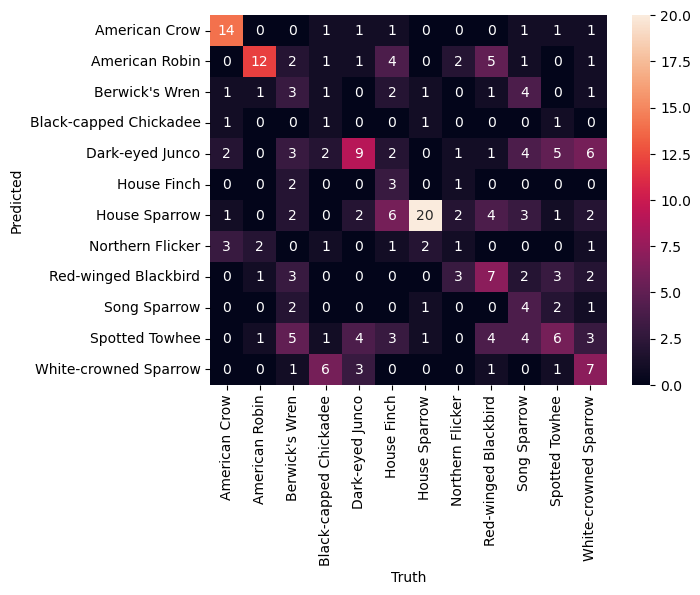

In [76]:
sns.heatmap(confusion_table(to_names(ym_pred),to_names(ym_truth)), annot=True)

# 3. External Test Data

In [45]:
test_files = [f"data/external_test_data/test{i}.mp3" for i in range(1,4)]
test_files

['data/external_test_data/test1.mp3',
 'data/external_test_data/test2.mp3',
 'data/external_test_data/test3.mp3']

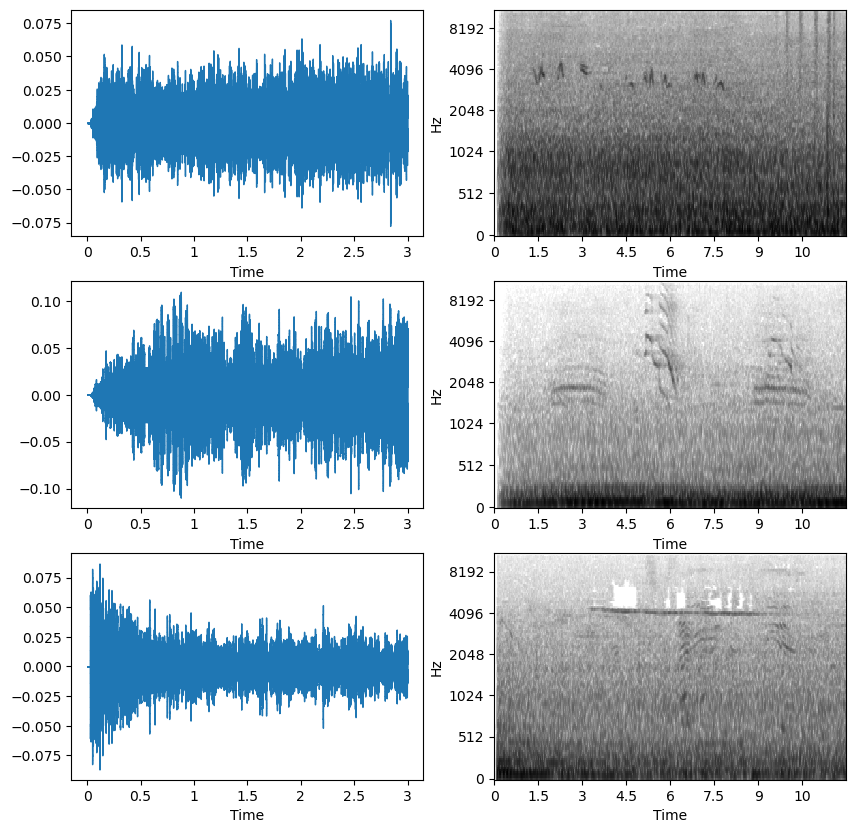

In [64]:
fig, ax = plt.subplots(nrows=3,ncols=2,figsize=(10,10))
spectrograms = []
for i,test_file in enumerate(test_files):
    y, sr = librosa.load(test_file, duration=3)
    librosa.display.waveshow(y, sr=sr, ax=ax[i][0])

    spec = librosa.feature.melspectrogram(y=y, sr=sr, hop_length=128, win_length=512)
    spec_db = librosa.power_to_db(spec, ref=np.max)
    librosa.display.specshow(spec_db, x_axis='time', y_axis='mel', sr=sr, cmap='gray_r',ax=ax[i][1])
    spectrograms.append(spec_db.flatten())


In [77]:
X_extest = np.vstack(spectrograms)
X_extest.shape

(3, 66176)

In [82]:
# lightweight prediction
np.array(species,dtype="<U6")[np.argmax(CNNm_light.predict(X_extest, verbose=0), axis=1)]

array(['sonspa', 'amerob', 'sonspa'], dtype='<U6')

In [ ]:
# heavyweight prediction
np.array(species,dtype="<U6")[np.argmax(CNNm_heavy.predict(X_extest, verbose=0), axis=1)]

array(['houspa', 'houspa', 'houspa'], dtype='<U6')